# Проект для «Викишоп» c BERT

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучим модель классифицировать комментарии на позитивные и негативные. В нашем распоряжении набор данных с разметкой о токсичности правок.

Построим модель со значением метрики качества *F1* не меньше 0.75. 

**Описание данных**

Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.целевой признак.

# 1. Подготовка данных

In [ ]:
#Импорт библиотек для работы с данными
import pandas as pd
import numpy as np

#Импорт библиотек для визуализации
from matplotlib import pyplot as plt
import seaborn as sns

#Импорт библиотек для машинного обучения и обработки данных
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from tqdm import notebook
import  torch
import transformers
from transformers import BertTokenizer, BertModel
import statistics
import pickle
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from wordcloud import WordCloud

In [ ]:
# выведем первые 5 строк нашего датасета
data.head()

In [ ]:
data.tail()

In [ ]:
# посмотрим на общую информацию о датафрейме
data.info()

Можно отметить разрыв в индексах — результат наличия пропущенных или удалённых строк в исходном файле. Хотя в датафрейме всего 159292 записи, индексы продолжают увеличиваться до 159450, поскольку часть строк могла быть пропущена или удалена на этапе предварительной обработки. Попробуем сбросить индексы

In [ ]:
# сбросим индексы
data.reset_index(drop=True, inplace=True)

In [ ]:
# посмотрим на обновленную общую информацию о датафрейме
data.info()

In [ ]:
#проверим наличие пропущенных значений
data.isna().sum()

Пропущенных данных не обнаружено

In [ ]:
#проверим наличие дубликатов
data.duplicated().sum()

Дубликатов не обнаружено

Далее посмотрим на распределение классов 

In [ ]:
# посмотрим на распределение классов
sns.countplot(x='toxic', data=data)
plt.title("Distribution of Target Variable (toxic)")
plt.xlabel("Toxic")
plt.ylabel("Count")
plt.show()

Согласно графику, у нас дисбаланс классов, который нужно либо исправить, либо учитывать при построении моделей. Посмотрим на процентное соотношение

In [11]:
# проверим распределение классов в процентах
class_distribution = data['toxic'].value_counts(normalize=True) * 100

In [12]:
class_distribution

Класс "1" составляет всего 10% от всего датасета. Это нужно либо исправить (использовать новые данные, либо сгенерировать с помощью SMOTE, ADASYN и др подходы) либо учитывать при обучении моделей в гиперепараметрах. Попробуем для начала учесть такую ситуацию в гиперпараметрах наших моделей. Также в качестве метрики мы будем использовать метрику f1, которая более устойчива к дисбалансу классов.

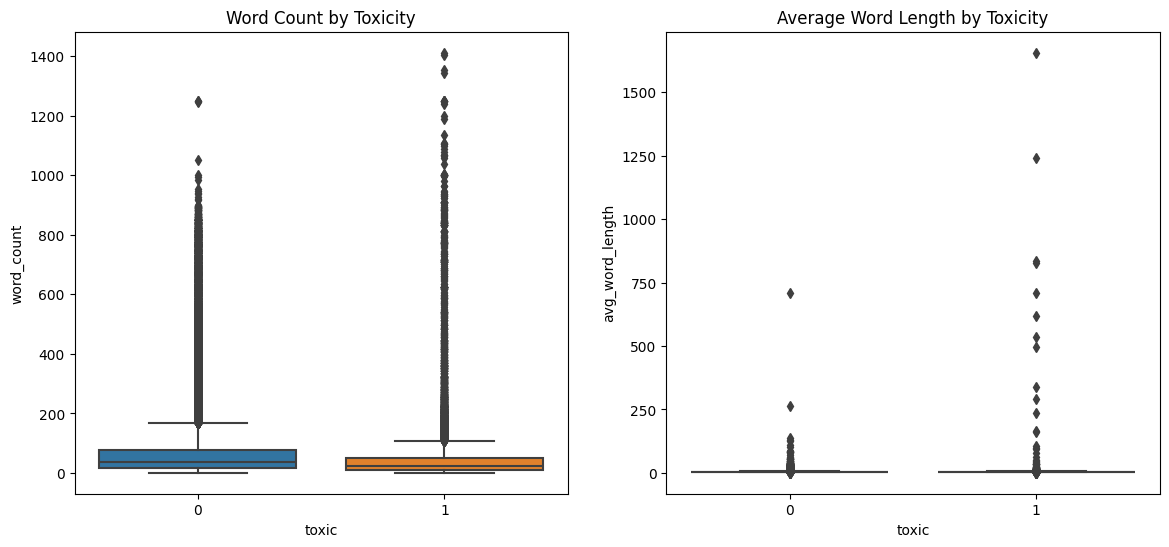

In [13]:
# попробуем добавить новые признаки: количество слов и средняя длина слов в каждом комментарии
data['word_count'] = data['text'].apply(lambda x: len(x.split()))
data['avg_word_length'] = data['text'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()))

# посмотрим на распределение новых признаков в зависимости от класса
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='toxic', y='word_count', data=data, ax=axes[0])
axes[0].set_title("Word Count by Toxicity")
sns.boxplot(x='toxic', y='avg_word_length', data=data, ax=axes[1])
axes[1].set_title("Average Word Length by Toxicity")
plt.show()

Согласно графику, сложно сказать, что в среднем токсичные комментарии короче, чем нетоксичные, хотя среди них тоже могут встречаться длинные сообщения. Токсичные комментарии имеют немного более длинные слова в среднем, хотя существуют отдельные аномальные комментарии, которые влияют на стандартное отклонение и максимальное значение.

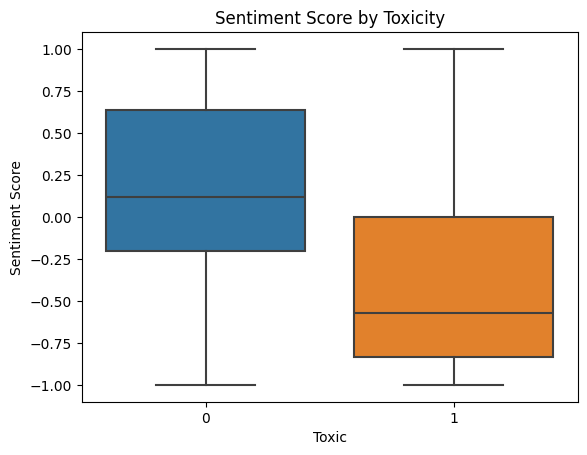

In [14]:
# проведем анализ тональности
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
data['sentiment'] = data['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# оценим корреляцию тональности с таргетом
sentiment_corr = data[['sentiment', 'toxic']].corr()
print(f"Correlation between sentiment and toxicity:\n{sentiment_corr}\n")

# построим график распределения оценки тональности по таргету
sns.boxplot(x='toxic', y='sentiment', data=data)
plt.title("Sentiment Score by Toxicity")
plt.xlabel("Toxic")
plt.ylabel("Sentiment Score")
plt.show()

Корреляция между оценкой тональности (sentiment) и токсичностью (toxic) равна примерно -0.29. Это означает, что между этими признаками существует слабая обратная связь: чем ниже оценка тональности (т.е. чем негативнее текст), тем больше вероятность, что комментарий будет помечен как токсичный. Однако коэффициент -0.29 все еще относительно мал, и это указывает на то, что тональность комментария не является сильным предиктором токсичности, но может внести определенный вклад. 

In [ ]:
# объединим все тексты в одну строку для каждой категории
toxic_comments = data[data['toxic'] == 1]['text'].str.cat(sep=' ')
non_toxic_comments = data[data['toxic'] == 0]['text'].str.cat(sep=' ')

# создадим облака слов
toxic_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(toxic_comments)
non_toxic_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(non_toxic_comments)

# визуализируем
plt.figure(figsize=(14, 6))

# построим облако слов для токсичных комментариев
plt.subplot(1, 2, 1)
plt.imshow(toxic_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Toxic Comments')

# построим облако слов для нетоксичных комментариев
plt.subplot(1, 2, 2)
plt.imshow(non_toxic_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Non-Toxic Comments')

plt.tight_layout()
plt.show()

Хм, интересная получилась визуализация:). В токсичных, наряду с ругательскими словами встречаются и вполне нормальные

Приступим к обработке текстовых данных для BERT

In [16]:
# инициализируем наш токенизатор
tokenizer = transformers.BertTokenizer(vocab_file = './data/vocab.txt')

In [17]:
# токенизируем каждый комментарий
tokenized = data['text'].apply(lambda x: tokenizer.encode(x, add_special_tokens = True))

In [18]:
# определим максимальную длину токенов
max_len = max([len(tokens) for tokens in tokenized])

In [19]:
max_len

Максимальная длина входной последовательности (4950) превышает максимальную длину, поддерживаемую моделью BERT, которая равна 512. Модель BERT рассчитана на обработку текстов до 512 токенов, и если текст длиннее, его нужно будет либо обрезать, либо разбивать на более короткие части. Попробуем посмотреть какая средняя длина токенов, а также распределение этой длины

In [20]:
# определим среднюю длину токенов
mean = statistics.mean([len(tokens) for tokens in tokenized])

In [21]:
mean

Посмотрим на боскплот по длине токенов

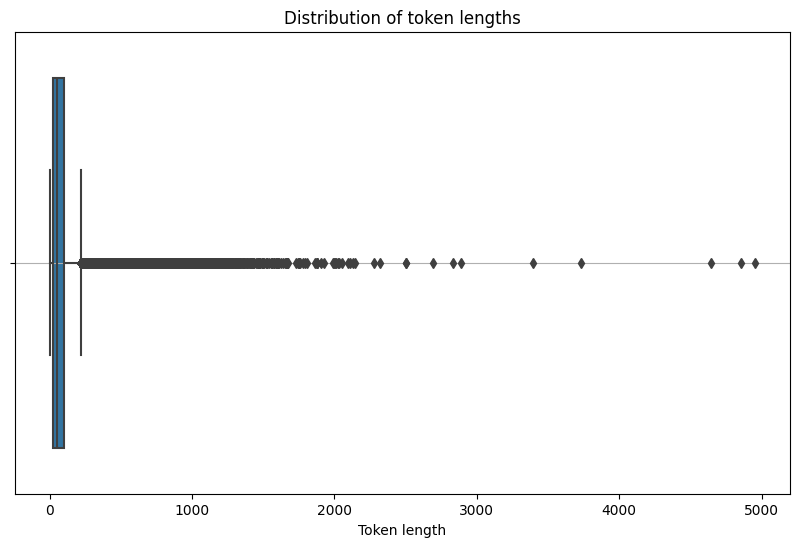

In [22]:
# Создадим список длин токенов
token_lengths = [len(tokens) for tokens in tokenized]

# Визуализируем распределение длин токенов с помощью box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=token_lengths)
plt.title('Distribution of token lengths')
plt.xlabel('Token length')
plt.grid(axis='y')
plt.show()

In [23]:
# Определяем порог для верхнего 1% и 5%
percentile_99 = np.percentile(token_lengths, 99)  # Верхний 1%
percentile_95 = np.percentile(token_lengths, 95)  # Верхний 5%

In [24]:
percentile_99 

In [25]:
percentile_95

In [26]:
tokenized = tokenized[tokenized.apply(lambda x: len(x) <= percentile_95)]

In [27]:
# определим максимальную длину токенов
max([len(tokens) for tokens in tokenized])

Считаем верхние 5% выбросами и удалим их из дальнейшего анализа

In [28]:
# устанавливаем максимальную длину последовательности
max_len = max([len(tokens) for tokens in tokenized])

# приведем данные к нужной длине
padded = np.array([i[:max_len] + [0] * (max_len - len(i[:max_len])) for i in tokenized])

In [29]:
# создадим attention_mask, гдк 1- реальные токены, а 0- добавленные нули (padding)
attention_mask = np.where(padded !=0,1,0)

Теперь в дело вступают тензоры

In [30]:
# инициализируем конфигурацию BertConfig, в качестве агрумента передадим json_file с описанием настроек модели
config = transformers.BertConfig.from_json_file(
    './data/config.json')

In [31]:
# инициализируем саму модель BertModel. Передадим ей файл с предобученной моделью и конфигурацией
model = transformers.BertModel.from_pretrained(
    './data/pytorch_model.bin', config=config)

Начнем преобразование текстов в Embedding. Подключим библиотеку tqdm

In [32]:
# сделаем размер батча 256
batch_size = 256

Пробовала использовать tqdm, но не получилось. Не корректно визуализировал прогресс. Пришлось перейти на print

In [33]:
# подготовим список для эмбеддингов
embeddings = []

# напишем цикл по батчам
num_batches = padded.shape[0] // batch_size  
for i in range(num_batches):
    print(f"Processing batch {i + 1}/{num_batches}")
    
    # преобразуем данные в формат тензоров
    batch = torch.LongTensor(padded[batch_size * i : batch_size * (i + 1)])
    attention_mask_batch = torch.LongTensor(attention_mask[batch_size * i : batch_size * (i + 1)])

    # получим эмбеддинги для батча с использованием no_grad
    with torch.no_grad():
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)
    
    # извлекем нужные элементы и добавим в список всех эмбеддингов
    embeddings.append(batch_embeddings[0][:, 0, :].numpy())

print("Processing complete!")

In [34]:
# проверим остаток батча
padded.shape[0] % batch_size

In [35]:
# сделаем проверку на неполный батч
remaining_items = padded.shape[0] % batch_size
if remaining_items > 0:
    # обработаем последний неполный батч
    print(f"Processing remaining batch of {remaining_items} items")
    batch = torch.LongTensor(padded[-remaining_items:])
    attention_mask_batch = torch.LongTensor(attention_mask[-remaining_items:])

    with torch.no_grad():
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)
    
    embeddings.append(batch_embeddings[0][:, 0, :].numpy())

In [36]:
# соберем все эмбеддинги в матрицу признаков вызовом функции concatenate()
features = np.concatenate(embeddings)

In [37]:
features.shape

Сохраним признаки

In [38]:
# сохраним с помощью pickle
with open("./data/embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)

In [39]:
# сохраним с помощью pickle
with open("./data/features.pkl", "wb") as f:
    pickle.dump(features, f)

In [40]:
features.shape

# Обучение модели

In [41]:
# определим целевую переменную
y = data['toxic']

In [42]:
y = y.loc[tokenized.index]
y = y.reset_index(drop=True)

In [43]:
y.info()

In [44]:
# разделим данные на обучающую и тестовую выборки 
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

In [45]:
y_train.value_counts()

У нас есть дисбаланс классов, поэтому учтем это в моделях

In [46]:
# Создаем пайплайн для классификации
pipe_final = Pipeline([
    ('model', RandomForestClassifier(random_state=42))  
]) 
param_grid = [
    {
        'model': [RandomForestClassifier(random_state=42)],
        'model__n_estimators': list(range(100, 1100, 200)),  
        'model__max_depth': [None] + list(range(10, 30, 5)), 
        'model__min_samples_leaf': list(range(1, 5)),  
        'model__min_samples_split': list(range(2, 11, 3)), 
        'model__bootstrap': [True, False],
        'model__class_weight': ['balanced', {0: 1, 1: 10}, None]
    },
    {
        'model': [LGBMClassifier(random_state=42, class_weight='balanced')],
        'model__n_estimators': list(range(800, 1001, 50)),  
        'model__learning_rate': [0.05, 0.06, 0.07, 0.08, 0.09], 
        'model__max_depth': [None, 10, 12],  
        'model__num_leaves': list(range(60, 80, 5)),  
        'model__min_child_samples': list(range(39, 50, 2)), 
        'model__reg_alpha': [0.5, 0.6, 0.7],  
        'model__reg_lambda': [0.4, 0.5, 0.6],  
        'model__scale_pos_weight':  list(range(1, 11, 2))  
    },
    {
        'model': [XGBClassifier(random_state=42, class_weight='balanced')],
        'model__n_estimators': list(range(100, 1100, 200)),  
        'model__learning_rate': [0.1, 0.2, 0.3, 0.4],
        'model__max_depth': list(range(3, 11, 2)), 
        'model__gamma': [0, 0.1, 0.3, 0.5],
        'model__min_child_weight': list(range(1, 11, 3)),  
        'model__reg_alpha': [0, 0.1, 0.5, 1.0],
        'model__reg_lambda': [0, 0.1, 0.5, 1.0],
        'model__scale_pos_weight': list(range(1, 11, 2))  
    },
    {
        'model': [LogisticRegression(max_iter=1500)],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
        'model__class_weight': ['balanced', {0: 1, 1: 10}, None]
    }
]

In [47]:
# Инициализация RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipe_final,
    param_distributions=param_grid,
    cv=10,  
    scoring='f1',  
    n_jobs=-1,
    n_iter = 20,
    random_state=42
)

# Обучение модели
random_search.fit(X_train, y_train)

In [48]:
f1_train = random_search.best_score_

In [49]:
random_search.best_estimator_

Лучшей моделью оказалась модель RandomForestClassifier со следующими параметрами: max_depth=15, min_samples_leaf=4, n_estimators=900, random_state=42

In [50]:
f1_train

In [51]:
# предскажем значения на тестовых данных
y_pred = random_search.predict(X_test)

# оценим модель с помощью метрики F1
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

Лучшая метрика f1 на обучающей выборке составила 0.9490, на тестовых данных -  0.9448.

In [55]:
# Инициализация DummyClassifier со стратегией 'most_frequent' для базовой модели
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

# Предсказание с помощью DummyClassifier на тестовых данных
y_dummy_pred = dummy_clf.predict(X_test)

# Оценка метрики F1 для DummyClassifier
f1_dummy = f1_score(y_test, y_dummy_pred)
print(f"Dummy F1 Score: {f1_dummy:.4f}")

Результат Dummy F1 Score: 0.0000 объясняется тем, что DummyClassifier со стратегией most_frequent всегда предсказывает один и тот же наиболее часто встречающийся класс. Поскольку целевая переменная toxic у нас несбалансирована, то есть один класс сильно преобладает над другим, DummyClassifier будет всегда предсказывать этот класс. Это приводит к нулевому значению F1-метрики для менее частого класса.

Сравнительно высокая f1-оценка для RandomForestClassifier на обучающих и тестовых данных говорит о том, что модель хорошо выявляет оба класса, включая более редкий. Она не только улавливает основные закономерности, но и способна различать классы лучше, чем простое предсказание самого частого значения.
В то же время близкие значения на обучающей и тестовой выборках (0.9490 и 0.9448) подтверждают, что модель не переобучена.

я использовала такую загрузку # инициализируем конфигурацию BertConfig, в качестве агрумента передадим json_file с описанием настроек модели
config = transformers.BertConfig.from_json_file(
    './data/config.json') и # инициализируем саму модель BertModel. Передадим ей файл с предобученной моделью и конфигурацией
model = transformers.BertModel.from_pretrained(
    './data/pytorch_model.bin', config=config). Скачивала файлы с  huggingface.

# Вывод

В рамках проекта был разработан инструмент для интернет-магазина "Викишоп" по автоматическому выявлению токсичных комментариев среди пользовательских правок и предложений. Этот инструмент позволит направлять потенциально оскорбительные и токсичные комментарии на модерацию, тем самым поддерживая дружественную и конструктивную атмосферу на платформе
Для достижения цели были выполнены следующие шаги. Датасет, содержащий тексты комментариев и метки токсичности был загружен, исследован и предобработан. С помощью BertTokenizer был токенизирован каждый комментарий, после чего были получены тензоры. В проекте была опробована предобученная модель BERT (unitary/toxic-bert), которая специализирована на выявление токсичных высказываний. С помощью данной модели были получены эмбеддинги для каждого комментария по батчам.
Для классификации были исследованы несколько алгоритмов, таких как: RandomForestClassifier, LGBMClassifier, XGBClassifier и LogisitcRegression. Для каждого из них был использован RandomizedSearchCV с кросс-валидацией для подбора гиперпараметров, оптимизируя метрику f1. Лучшей моделью оказалась модель RandomForestClassifier со следующими параметрами: max_depth=15, min_samples_leaf=4, n_estimators=900, random_state=42. Лучшая метрика f1 на обучающей выборке составила 0.9490, на тестовых данных - 0.9448.  Близкие значения на обучающей и тестовой выборках (0.9490 и 0.9448) подтверждают, что модель не переобучена. Модель показала значительное превосходство по сравнению с константной моделью DummyClassifier, что подтверждает эффективность подхода к созданию признаков и проведению кросс-валидации.